In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [112]:
df = pd.read_csv("user_analysis.csv")
df

,new_user,age,sex,market,device,operative_system,source,total_pages_visited,home_page,listing_page,product_page,payment_page,confirmation_page
0,1,29,Female,1,Desktop,Windows,Ads,3,1,1,1,0,0
1,1,25,Female,1,Mobile,iOS,Direct,4,1,1,1,0,0
2,1,24,Male,4,Desktop,Windows,Seo,4,1,1,1,0,0
3,1,22,Male,3,Desktop,Windows,Seo,2,1,1,0,0,0
4,1,32,Female,1,Desktop,Mac,Ads,2,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31115,1,36,Male,3,Mobile,Android,Seo,11,1,1,0,0,0
31116,1,38,Male,1,Desktop,Mac,Seo,11,1,1,1,0,0
31117,1,37,Female,1,Mobile,Android,Seo,5,1,1,1,0,0
31118,1,25,Female,3,Mobile,Android,Seo,15,1,1,1,0,0


In [113]:
total_user = len(df)
total_user

31120

# 1. 新用户画像分布分析

## 1.1 人口属性分布

### 1.1.1 年龄段分布

In [114]:
# 分段边界 (左开右闭)
bins = [16, 22, 28, 38, 50, 67]
# 每一段对应的文字标签
labels = ['17-22岁', '23-28岁', '29-38岁', '39-50岁', '51-67岁']
df['age_group'] = pd.cut(df['age'], bins = bins, labels = labels)
df

,new_user,age,sex,market,device,operative_system,source,total_pages_visited,home_page,listing_page,product_page,payment_page,confirmation_page,age_group
0,1,29,Female,1,Desktop,Windows,Ads,3,1,1,1,0,0,29-38岁
1,1,25,Female,1,Mobile,iOS,Direct,4,1,1,1,0,0,23-28岁
2,1,24,Male,4,Desktop,Windows,Seo,4,1,1,1,0,0,23-28岁
3,1,22,Male,3,Desktop,Windows,Seo,2,1,1,0,0,0,17-22岁
4,1,32,Female,1,Desktop,Mac,Ads,2,1,1,0,0,0,29-38岁
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31115,1,36,Male,3,Mobile,Android,Seo,11,1,1,0,0,0,29-38岁
31116,1,38,Male,1,Desktop,Mac,Seo,11,1,1,1,0,0,29-38岁
31117,1,37,Female,1,Mobile,Android,Seo,5,1,1,1,0,0,29-38岁
31118,1,25,Female,3,Mobile,Android,Seo,15,1,1,1,0,0,23-28岁


In [115]:
age_dist = df['age_group'].value_counts().sort_index()
age_df = pd.DataFrame({
    '人数': age_dist,
    '占比(%)': round(age_dist / total_user * 100, 2)
})
age_df

,人数,占比(%)
age_group,,
17-22岁,5602,18.00
23-28岁,8151,26.19
29-38岁,12197,39.19
39-50岁,4803,15.43
51-67岁,367,1.18


### 1.1.2 性别分布

In [116]:
sex_dist = df['sex'].value_counts()
sex_df = pd.DataFrame({
    '人数': sex_dist,
    '占比(%)': round(sex_dist / total_user * 100, 2)
})
sex_df

,人数,占比(%)
sex,,
Female,18917,60.79
Male,12203,39.21


### 1.1.3 市场地区分布

In [117]:
market_dist = df['market'].value_counts()
market_df = pd.DataFrame({
    '人数': market_dist,
    '占比(%)': round(market_dist / total_user * 100, 2)
})
market_df

,人数,占比(%)
market,,
1,18074,58.08
3,5551,17.84
2,5532,17.78
4,1963,6.31


## 2.1 访问环境分布

### 2.1.1 设备分布

In [118]:
device_dist = df['device'].value_counts()
device_df = pd.DataFrame({
    '人数': device_dist,
    '占比(%)': round(device_dist / total_user * 100, 2)
})
device_df

,人数,占比(%)
device,,
Mobile,18931,60.83
Desktop,12189,39.17


### 2.1.2 操作系统分布

In [119]:
os_dist = df['operative_system'].value_counts()
os_df = pd.DataFrame({
    '人数': os_dist,
    '占比(%)': round(os_dist / total_user * 100, 2)
})
os_df

,人数,占比(%)
operative_system,,
Windows,9196,29.55
iOS,8819,28.34
Android,8755,28.13
Mac,2651,8.52
Other,1361,4.37
Linux,338,1.09


### 2.1.3 流量渠道分布

In [120]:
source_dist = df['source'].value_counts()
source_df = pd.DataFrame({
    '人数': source_dist,
    '占比(%)': round(source_dist / total_user * 100, 2)
})
source_df

,人数,占比(%)
source,,
Seo,18588,59.73
Ads,10305,33.11
Direct,2227,7.16


# == 画像大盘分析结论 ==

In [121]:
# 主流年龄段
main_age = age_df['人数'].idxmax()
# 主流性别
main_sex = sex_df['人数'].idxmax()
# 核心市场
main_market = market_df['人数'].idxmax()
# 主流设备
main_device = device_df['人数'].idxmax()
# 主流系统
main_os = os_df['人数'].idxmax()
# 核心渠道
main_source = source_df['人数'].idxmax()

In [122]:
conclusion = f"""
1. 主流人群：{main_age}群体占比最高，核心性别为{main_sex}，流量集中在{main_market}市场;
2. 主流设备：绝大多数用户使用{main_device}访问；
3. 主流操作系统：{main_os}用户数量遥遥领先；
4. 核心流量渠道：{main_source}是平台最主要的新客来源；
业务认知：平台新客以{main_age}移动端用户为主，流量高度依赖该核心渠道，后续运营可重点针对该人群做优化。
"""
conclusion

'\n1. 主流人群：29-38岁群体占比最高，核心性别为Female，流量集中在1市场;\n2. 主流设备：绝大多数用户使用Mobile访问；\n3. 主流操作系统：Windows用户数量遥遥领先；\n4. 核心流量渠道：Seo是平台最主要的新客来源；\n业务认知：平台新客以29-38岁移动端用户为主，流量高度依赖该核心渠道，后续运营可重点针对该人群做优化。\n'

In [123]:
with pd.ExcelWriter('新用户画像大盘.xlsx') as writer:
    age_df.to_excel(writer, sheet_name='年龄段')
    sex_df.to_excel(writer, sheet_name='性别')
    market_df.to_excel(writer, sheet_name='市场地区')
    device_df.to_excel(writer, sheet_name='设备')
    os_df.to_excel(writer, sheet_name='操作系统')
    source_df.to_excel(writer, sheet_name='流量渠道')

# 2. 用户浏览行为整体分析

## 2.1 人均总访问页数 (浏览深度)

In [124]:
# 页面字段集合
page_cols = ['home_page', 'listing_page', 'product_page', 'payment_page', 'confirmation_page']
avg_total_page = round(df['total_pages_visited'].mean(),2)
avg_total_page

np.float64(6.26)

## 2.2 浏览深度分层：浅/中/深浏览

In [125]:
 def get_depth_level(page_num):
     if page_num <=3:
         return '浅浏览'
     elif 4 <= page_num <= 10:
         return '中浏览'
     else:
         return '深浏览'

In [126]:
df['browse_depth'] = df['total_pages_visited'].apply(get_depth_level)
df

,new_user,age,sex,market,device,operative_system,source,total_pages_visited,home_page,listing_page,product_page,payment_page,confirmation_page,age_group,browse_depth
0,1,29,Female,1,Desktop,Windows,Ads,3,1,1,1,0,0,29-38岁,浅浏览
1,1,25,Female,1,Mobile,iOS,Direct,4,1,1,1,0,0,23-28岁,中浏览
2,1,24,Male,4,Desktop,Windows,Seo,4,1,1,1,0,0,23-28岁,中浏览
3,1,22,Male,3,Desktop,Windows,Seo,2,1,1,0,0,0,17-22岁,浅浏览
4,1,32,Female,1,Desktop,Mac,Ads,2,1,1,0,0,0,29-38岁,浅浏览
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31115,1,36,Male,3,Mobile,Android,Seo,11,1,1,0,0,0,29-38岁,深浏览
31116,1,38,Male,1,Desktop,Mac,Seo,11,1,1,1,0,0,29-38岁,深浏览
31117,1,37,Female,1,Mobile,Android,Seo,5,1,1,1,0,0,29-38岁,中浏览
31118,1,25,Female,3,Mobile,Android,Seo,15,1,1,1,0,0,23-28岁,深浏览


In [127]:
browse_dist = df['browse_depth'].value_counts()
browse_df = pd.DataFrame({
    '用户数量': browse_dist,
    '占比(%)': round(browse_dist / total_user  * 100, 2)
})
browse_df

,用户数量,占比(%)
browse_depth,,
中浏览,15984,51.36
浅浏览,10445,33.56
深浏览,4691,15.07


## 2.3 各页面访问渗透率 (用户偏好页面)

In [128]:
page_visit_cnt = df[page_cols].sum()
page_visit_rate = page_visit_cnt / total_user
page_analyse_df = pd.DataFrame({
    '访问用户数': page_visit_cnt,
    '页面渗透率(%)': round(page_visit_rate * 100, 2)
})
page_analyse_df = page_analyse_df.sort_values('页面渗透率(%)',ascending=False)
page_analyse_df

,访问用户数,页面渗透率(%)
home_page,31120,100.00
listing_page,22920,73.65
product_page,15107,48.54
payment_page,1807,5.81
confirmation_page,458,1.47


# == 用户浏览行为分析结论 ==

In [129]:
# 主流深度浏览
main_depth = browse_df['用户数量'].idxmax()
# 主流页面
fav_page = page_analyse_df.index[0]

In [130]:
depth_conclusion = f"""
1. 整体浏览深度：新用户人均访问 {avg_total_page} 页面，整体浏览偏浅；
2. 用户分层结构：{main_depth} 用户占比最高，平台大部分新用户仅少量浏览页面；
3. 用户偏好页面：{fav_page} 渗透率远高于其他页面，是用户最常访问页面；
4. 业务机会：大量浅浏览用户未进入商品/支付环节，需优化首页引导提升浏览深度。
"""
depth_conclusion

'\n1. 整体浏览深度：新用户人均访问 6.26 页面，整体浏览偏浅；\n2. 用户分层结构：中浏览 用户占比最高，平台大部分新用户仅少量浏览页面；\n3. 用户偏好页面：home_page 渗透率远高于其他页面，是用户最常访问页面；\n4. 业务机会：大量浅浏览用户未进入商品/支付环节，需优化首页引导提升浏览深度。\n'

In [131]:
with pd.ExcelWriter('新用户画像大盘.xlsx', mode='a', if_sheet_exists='replace') as writer:
    browse_df.to_excel(writer, sheet_name='浏览深度分层')
    page_analyse_df.to_excel(writer, sheet_name='页面访问渗透率')

# 3. 搭建全局转化漏斗，定位核心流失卡点

## 3.1 漏斗各环节访问人数

In [132]:
home_cnt = df['home_page'].sum()
list_cnt = df['listing_page'].sum()
product_cnt = df['product_page'].sum()
payment_cnt = df['payment_page'].sum()
confirmation_cnt = df['confirmation_page'].sum()

In [133]:
# 组装漏斗基础数据
funnel_data = pd.DataFrame({
    '页面环节':['首页', '列表页', '商品详情页', '支付页', '订单确认页'],
    '用户数': [home_cnt, list_cnt, product_cnt, payment_cnt, confirmation_cnt]
})
funnel_data

,页面环节,用户数
0,首页,31120
1,列表页,22920
2,商品详情页,15107
3,支付页,1807
4,订单确认页,458


## matplotlib 漏斗可视化绘图 

In [134]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [135]:
# 提取绘图数据
# Y轴标签
labels = funnel_data['页面环节'].tolist()
# 条形长度数值
values = funnel_data['用户数'].tolist()
max_val = max(values)

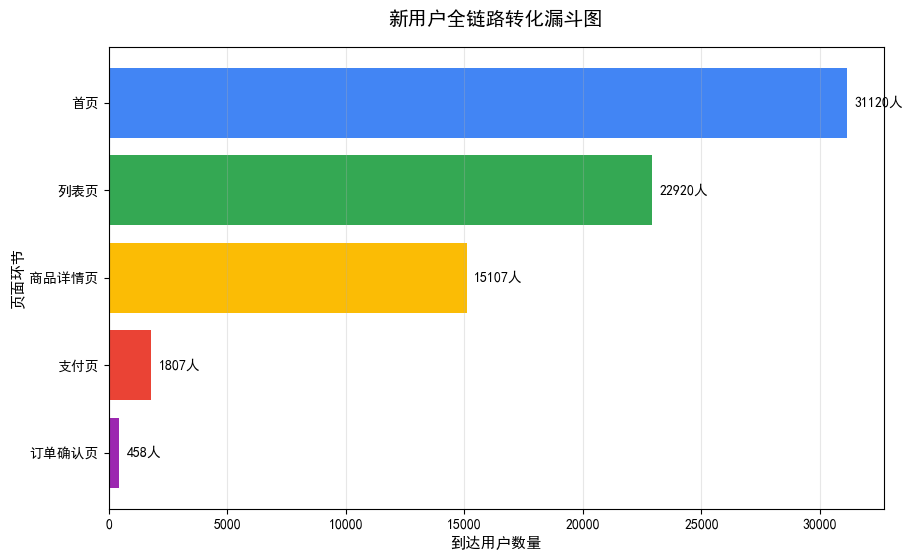

In [136]:
# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4285F4", "#34A853", "#FBBC05", "#EA4335", "#9C27B0"]

# 绘制横向条形漏斗图
bars = ax.barh(labels, values, color=colors)

# 倒转y轴，首页放最上方
ax.invert_yaxis()

# 在每个条形上标注人数
for bar in bars:
    width = bar.get_width()
    ax.text(width + max_val * 0.01, 
            bar.get_y() + bar.get_height()/2,
            f"{int(width)}人", 
            va="center", 
            fontsize=10)

# 图表标题、坐标轴
ax.set_title("新用户全链路转化漏斗图", fontsize=14, pad=15)
ax.set_xlabel("到达用户数量", fontsize=11)
ax.set_ylabel("页面环节", fontsize=11)
ax.grid(axis="x", alpha=0.3)

## 3.2 整体新用户转化率

In [137]:
total_convert_rate = confirmation_cnt / total_user
total_convert_rate

np.float64(0.014717223650385605)

## 3.3 各环节递进转化率、流失率

In [138]:
funnel_step = [
    ('首页->列表页', home_cnt, list_cnt),
    ('列表页->商品详情页', list_cnt, product_cnt),
    ('商品详情页->支付页', product_cnt, payment_cnt),
    ('支付页->订单确认页', payment_cnt, confirmation_cnt)
]
step_result = []

In [139]:
for step_name, prev_num, curr_num in funnel_step:
    if prev_num == 0:
        convert = 0
        loss = 1
    else:
        convert = curr_num / prev_num
        loss = 1 - convert
    step_result.append({
        '转化环节': step_name,
        '上一环节人数': prev_num,
        '本环节人数': curr_num,
        '递进转化率(%)': round(convert * 100, 4),
        '环节流失率(%)': round(loss * 100, 4)
    })    

In [140]:
step_df = pd.DataFrame(step_result)
step_df

,转化环节,上一环节人数,本环节人数,递进转化率(%),环节流失率(%)
0,首页->列表页,31120,22920,73.6504,26.3496
1,列表页->商品详情页,22920,15107,65.9119,34.0881
2,商品详情页->支付页,15107,1807,11.9613,88.0387
3,支付页->订单确认页,1807,458,25.3459,74.6541


## 3.4 筛选流失率最高的2个核心卡点

In [255]:
# 按流失率降序排序
step_df_sort = step_df.sort_values('环节流失率(%)',ascending=False)
Top2_loss = step_df_sort.head(2)
Top2_loss

,转化环节,上一环节人数,本环节人数,递进转化率(%),环节流失率(%)
2,商品详情页->支付页,15107,1807,11.9613,88.0387
3,支付页->订单确认页,1807,458,25.3459,74.6541


# == 漏斗流失分析结论 ==

In [142]:
top1_name = Top2_loss.iloc[0]['转化环节']
top1_loss = Top2_loss.iloc[0]['环节流失率(%)']
top2_name = Top2_loss.iloc[1]['转化环节']
top2_loss = Top2_loss.iloc[1]['环节流失率(%)']

In [143]:
funnel_conclusion = f"""
1. 全局转化表现：平台新用户整体下单转化率仅 {total_convert_rate}%；
2. 第一大流失卡点：{top1_name}，环节流失率 {top1_loss}%，是用户流失最严重节点；
3. 第二大流失卡点：{top2_name}，环节流失率 {top2_loss}%，次要流失节点；
4. 分析切入点：后续将围绕这两个高流失环节，从渠道、行为、人群维度拆解流失根因。
"""

In [144]:
with pd.ExcelWriter('新用户画像大盘.xlsx', mode = 'a', if_sheet_exists='replace') as writer:
    funnel_data.to_excel(writer, sheet_name='漏斗到达人数', index=False)
    step_df.to_excel(writer, sheet_name='环节转化流失明细', index=False)
    Top2_loss.to_excel(writer, sheet_name='TOP2高流失环节', index=False)

# 4. 渠道维度拆解 (流量质量诊断)

In [145]:
def calc_channel_funnel(sub_df):
    channel_total = len(sub_df)
    h = sub_df['home_page'].sum()
    l = sub_df['listing_page'].sum()
    p = sub_df['product_page'].sum()
    pay = sub_df['payment_page'].sum()
    conf = sub_df['confirmation_page'].sum()

    h2l = l / h if h else 0
    l2p = p / l if l else 0
    p2pay = pay / p if p else 0
    pay2conf = conf / pay if conf else 0
    total_convert = conf / channel_total if channel_total else 0

    return {
        '渠道总用户': channel_total,
        '首页到达': h,
        '列表到达': l,
        '商品到达': p,
        '支付到达': pay,
        '确认下单': conf,
        '首页->列表转化率': round(h2l, 4),
        '列表->商品转化率': round(l2p, 4),
        '商品->支付转化率': round(p2pay, 4),
        '支付->确认转化率': round(pay2conf, 4),
        '渠道整体下单转化率': round(total_convert, 4)     
    }

## 4.1 各渠道完整漏斗指标

In [146]:
channel_all_result = {}
for channel_name, sub_data in df.groupby('source'):
    channel_all_result[channel_name] = calc_channel_funnel(sub_data)
channel_df = pd.DataFrame(channel_all_result).T
channel_df = channel_df.reset_index().rename(columns = {'index':'渠道名称'})
channel_df

,渠道名称,渠道总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页->列表转化率,列表->商品转化率,商品->支付转化率,支付->确认转化率,渠道整体下单转化率
0,Ads,10305.0,10305.0,7574.0,4982.0,632.0,171.0,0.7350,0.6578,0.1269,0.2706,0.0166
1,Direct,2227.0,2227.0,1642.0,1093.0,105.0,19.0,0.7373,0.6657,0.0961,0.1810,0.0085
2,Seo,18588.0,18588.0,13704.0,9032.0,1070.0,268.0,0.7372,0.6591,0.1185,0.2505,0.0144


## 4.2 渠道四象限分层 (以渠道流量中位数、转化率中位数为分界线)

In [147]:
flow_median = channel_df['渠道总用户'].median()
convert_median = channel_df['渠道整体下单转化率'].median()

In [148]:
def get_quadrant(row):
    user_num = row['渠道总用户']
    convert = row['渠道整体下单转化率']
    if user_num >= flow_median and convert >= convert_median:
        return '高流量高转化(优质渠道)'
    elif user_num >= flow_median and convert < convert_median:
        return '高流量低转化(劣质渠道)'
    elif user_num < flow_median and convert >= convert_median:
        return '低流量高转化(潜力小众渠道)'
    else:
        return '低流量低转化(低效渠道)'

channel_df['渠道四象限标签'] = channel_df.apply(get_quadrant, axis = 1)
quadrant_group = channel_df.groupby('渠道四象限标签')[["渠道名称","渠道总用户","渠道整体下单转化率"]].apply(lambda x:x)
quadrant_group

渠道名称    渠道总用户  渠道整体下单转化率
渠道四象限标签                                   
低流量低转化(低效渠道) 1  Direct   2227.0     0.0085
高流量高转化(优质渠道) 0     Ads  10305.0     0.0166
             2     Seo  18588.0     0.0144

## 4.3 提取劣质渠道、优质小众渠道

In [149]:
bad_channel = channel_df[channel_df['渠道四象限标签'] == '高流量低转化(劣质渠道)']
good_small_channel = channel_df[channel_df['渠道四象限标签'] == '低流量高转化(潜力小众渠道)']

## 四象限散点可视化 (渠道流量&转化分布)

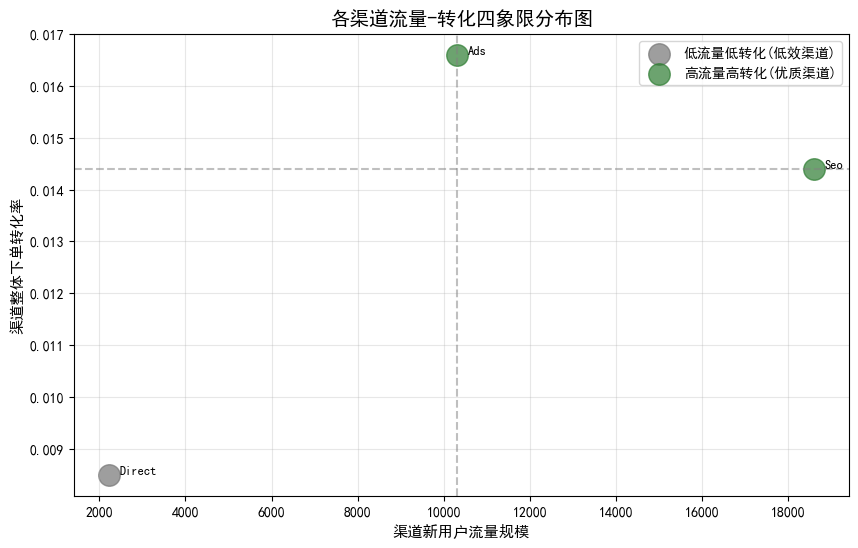

In [150]:
fig, ax = plt.subplots(figsize=(10, 6))
quad_color_map = {
    "高流量高转化(优质渠道)": "#2E7D32",
    "高流量低转化(劣质渠道)": "#C62828",
    "低流量高转化(潜力小众渠道)": "#1565C0",
    "低流量低转化(低效渠道)": "#757575"
}
# 绘制散点
for quad, group in channel_df.groupby('渠道四象限标签'):
    ax.scatter(group['渠道总用户'], group["渠道整体下单转化率"],
              color = quad_color_map[quad], label = quad, s=240, alpha=0.7)
    # 标注渠道名称
    for _,row in group.iterrows():
        ax.text(row['渠道总用户']+250, row['渠道整体下单转化率'], row["渠道名称"], fontsize=9)

# 中位数分割线
ax.axvline(x=flow_median, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y=convert_median, color="gray", linestyle="--", alpha=0.5)

ax.set_title("各渠道流量-转化四象限分布图", fontsize=14)
ax.set_xlabel("渠道新用户流量规模", fontsize=11)
ax.set_ylabel("渠道整体下单转化率", fontsize=11)
ax.legend(loc="best")
ax.grid(alpha=0.3)

# == 渠道流量质量诊断结论 ==

In [151]:
if len(bad_channel) > 0:
    bad_list = bad_channel['渠道名称'].tolist()
    print(f"1. 投放问题：{bad_list} 属于高流量低转化劣质渠道，用户进入平台后全链路流失严重，大盘核心流失卡点大概率由该类渠道低质量流量导致；")
else:
    print("1. 所有大流量渠道转化水平均达标，渠道投放质量无明显短板;")

1. 所有大流量渠道转化水平均达标，渠道投放质量无明显短板;


In [152]:
if len(good_small_channel) > 0:
    good_list = good_small_channel['渠道名称'].tolist()
    print(f"2. 增长机会：{good_list} 小众渠道用户精准度高、转化表现优异，可加大预算倾斜放大优质流量；")
else:
    print("2. 暂无高转化潜力小众渠道;")

2. 暂无高转化潜力小众渠道;


In [153]:
#print(f"3. 根因判断：全局TOP2流失环节{Top2_loss.iloc[0]['转化环节']}、{Top2_loss.iloc[1]['转化环节']}，劣质渠道在上述环节流失率显著高于均值，低质量投放是大盘流失重要诱因。")

In [154]:
print(f"3. 根因判断：全局TOP2流失环节{Top2_loss.iloc[0]['转化环节']}、{Top2_loss.iloc[1]['转化环节']}，全渠道在上述环节均存在明显流失，无低质量大流量渠道拖累，流失核心为产品/页面流程通用问题；")

3. 根因判断：全局TOP2流失环节商品详情页->支付页、支付页->订单确认页，全渠道在上述环节均存在明显流失，无低质量大流量渠道拖累，流失核心为产品/页面流程通用问题；


In [155]:
with pd.ExcelWriter("新用户画像大盘.xlsx", mode="a", if_sheet_exists="replace") as writer:
    channel_df.to_excel(writer, sheet_name="全渠道漏斗指标", index=False)

# 5. 设备&操作系统维度拆解（页面适配诊断）

In [156]:
def calc_group_funnel(sub_df):
    group_total = len(sub_df)
    h = sub_df["home_page"].sum()
    l = sub_df["listing_page"].sum()
    p = sub_df["product_page"].sum()
    pay = sub_df["payment_page"].sum()
    conf = sub_df["confirmation_page"].sum()

    h2l = l / h if h != 0 else 0
    l2p = p / l if l != 0 else 0
    p2pay = pay / p if p != 0 else 0
    pay2conf = conf / pay if pay != 0 else 0
    total_convert = conf / group_total if group_total != 0 else 0

    return {
        '分组总用户': group_total,
        '首页到达': h,
        '列表到达': l,
        '商品到达': p,
        '支付到达': pay,
        '确认下单': conf,
        '首页→列表转化率': round(h2l, 4),
        '列表→商品转化率': round(l2p, 4),
        '商品→支付转化率': round(p2pay, 4),
        '支付→确认转化率': round(pay2conf, 4),
        '分组整体下单转化率': round(total_convert, 4)
    }

## 5.1 各设备类型完整转化对比

In [157]:
device_result = {}
for device_name, sub_data in df.groupby('device'):
    device_result[device_name] = calc_group_funnel(sub_data)
device_df = pd.DataFrame(device_result).T.reset_index().rename(columns={'index':'设备类型'})
device_df

,设备类型,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,Desktop,12189.0,12189.0,8850.0,5890.0,700.0,186.0,0.7261,0.6655,0.1188,0.2657,0.0153
1,Mobile,18931.0,18931.0,14070.0,9217.0,1107.0,272.0,0.7432,0.6551,0.1201,0.2457,0.0144


提取各设备数据，对比支付环节流失

In [158]:
mobile_data = device_df[device_df['设备类型'] == 'Mobile']
pc_data = device_df[device_df['设备类型'] == 'Desktop']
mobile_pay_loss = 1 - mobile_data['支付→确认转化率'].values[0] if len(mobile_data) > 0 else 0
pc_pay_loss = 1 - pc_data['支付→确认转化率'].values[0] if len(pc_data) > 0 else 0
pay_loss_gap = mobile_pay_loss - pc_pay_loss
pay_loss_gap

np.float64(0.020000000000000018)

## 设备端转化率对比柱状图

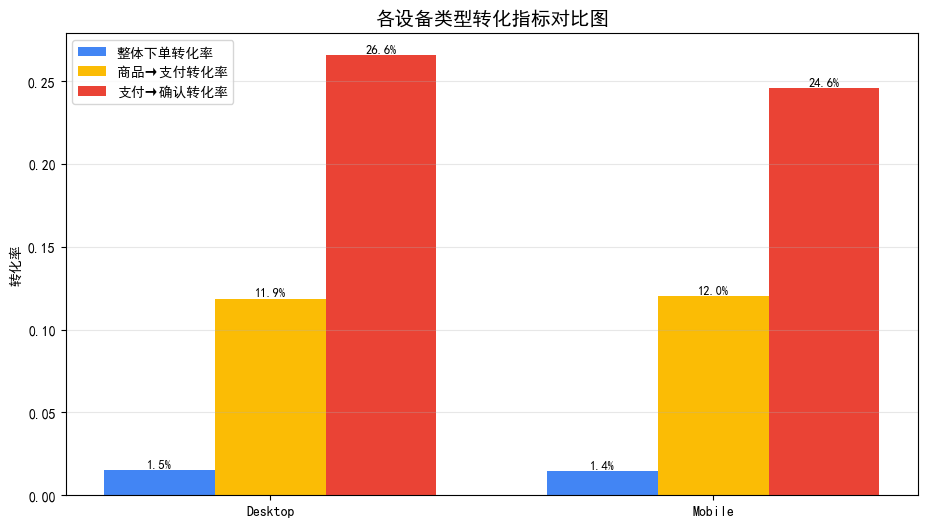

In [159]:
fig, ax = plt.subplots(figsize = (11, 6))
x = np.arange(len(device_df['设备类型']))
width = 0.25

# 三组对比：整体转化率、商品→支付、支付→确认
bar1 = ax.bar(x - width, device_df["分组整体下单转化率"], width, label='整体下单转化率', color="#4285F4")
bar2 = ax.bar(x, device_df["商品→支付转化率"], width, label="商品→支付转化率", color="#FBBC05")
bar3 = ax.bar(x + width, device_df["支付→确认转化率"], width, label="支付→确认转化率", color="#EA4335")

# 数值标注
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1%}', ha="center", va='bottom', fontsize=9)

ax.set_title("各设备类型转化指标对比图", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(device_df["设备类型"])
ax.set_ylabel("转化率")
ax.legend()
ax.grid(axis="y", alpha=0.3)

## 5.2 各操作系统完整转化对比

In [160]:
os_result = {}
for os_name, sub_data in df.groupby('operative_system'):
    os_result[os_name] = calc_group_funnel(sub_data)
os_df = pd.DataFrame(os_result).T.reset_index().rename(columns={'index':'操作系统'})
os_df

,操作系统,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,Android,8755.0,8755.0,6578.0,4282.0,546.0,141.0,0.7513,0.6510,0.1275,0.2582,0.0161
1,Linux,338.0,338.0,243.0,165.0,24.0,7.0,0.7189,0.6790,0.1455,0.2917,0.0207
2,Mac,2651.0,2651.0,1955.0,1305.0,180.0,72.0,0.7375,0.6675,0.1379,0.4000,0.0272
3,Other,1361.0,1361.0,996.0,660.0,59.0,6.0,0.7318,0.6627,0.0894,0.1017,0.0044
4,Windows,9196.0,9196.0,6650.0,4420.0,496.0,107.0,0.7231,0.6647,0.1122,0.2157,0.0116
5,iOS,8819.0,8819.0,6498.0,4275.0,502.0,125.0,0.7368,0.6579,0.1174,0.2490,0.0142


筛选全链路转化极差的小众系统（整体转化率低于全局均值）

In [161]:
global_avg_convert = total_convert_rate
# 低于大盘60%判定为极差小众系统
bad_os = os_df[os_df['分组整体下单转化率'] < global_avg_convert * 0.6]
bad_os

,操作系统,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
3,Other,1361.0,1361.0,996.0,660.0,59.0,6.0,0.7318,0.6627,0.0894,0.1017,0.0044


# == 设备&操作系统适配诊断结论 ==

In [162]:
# 手机支付流失判断
if pay_loss_gap > 0.15:
    print(f"1. 支付适配风险：手机端支付环节流失率{mobile_pay_loss:.0%}，电脑端{pc_pay_loss:.0%}，差值高达{pay_loss_gap:.0%}；手机页面加载、支付弹窗、收银台兼容性存在明显问题，是支付环节高流失核心诱因。")
else:
    print(f"1. 支付适配正常：手机与电脑端支付流失差距仅{pay_loss_gap:.0%}，移动端收银台页面无明显兼容缺陷。")

1. 支付适配正常：手机与电脑端支付流失差距仅2%，移动端收银台页面无明显兼容缺陷。


In [163]:
# 小众系统判断
if len(bad_os) >0:
    bad_os_list = bad_os['操作系统'].tolist()
    print(f"2. 系统兼容短板：{bad_os_list} 这类小众操作系统整体转化远低于大盘，页面渲染、接口适配存在缺陷，用户全链路流失严重。")
else:
    print("2. 系统兼容无短板：所有操作系统转化水平均衡，无小众系统适配故障。")

2. 系统兼容短板：['Other'] 这类小众操作系统整体转化远低于大盘，页面渲染、接口适配存在缺陷，用户全链路流失严重。


In [164]:
# 联动全局流失卡点综合根因
print(f"3. 综合根因判断：全局两大流失环节{Top2_loss.iloc[0]['转化环节']}、{Top2_loss.iloc[1]['转化环节']}；")
if pay_loss_gap > 0.15 or len(bad_os) > 0:
    print("   设备/系统维度存在明显适配缺陷，页面加载、收银台、页面交互兼容性问题放大了全链路流失，属于前端产品适配类问题。")
else:
    print("   各设备、操作系统转化表现无明显分化，流失并非页面适配导致，需聚焦产品流程、定价、活动等通用问题优化。")


3. 综合根因判断：全局两大流失环节商品详情页->支付页、支付页->订单确认页；
   设备/系统维度存在明显适配缺陷，页面加载、收银台、页面交互兼容性问题放大了全链路流失，属于前端产品适配类问题。


In [165]:
with pd.ExcelWriter("新用户画像大盘.xlsx", mode="a", if_sheet_exists="replace") as writer:
    device_df.to_excel(writer, sheet_name="设备转化明细", index=False)
    os_df.to_excel(writer, sheet_name="操作系统转化明细", index=False)
    bad_os.to_excel(writer, sheet_name="低转化小众系统", index=False)

# 6. 用户画像维度拆解-人群匹配度诊断

## 6.1 性别sex分组：转化、页面到达人数对比

In [166]:
sex_result = {}
for sex_name, sub_data in df.groupby('sex'):
    sex_result[sex_name] = calc_group_funnel(sub_data)
sex_df = pd.DataFrame(sex_result).T.reset_index().rename(columns = {'index':'性别'})
sex_df

,性别,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,Female,18917.0,18917.0,14010.0,9312.0,1186.0,333.0,0.7406,0.6647,0.1274,0.2808,0.0176
1,Male,12203.0,12203.0,8910.0,5795.0,621.0,125.0,0.7301,0.6504,0.1072,0.2013,0.0102


In [167]:
# 识别高低转化性别
max_sex_row = sex_df.loc[sex_df['分组整体下单转化率'].idxmax()]
min_sex_row = sex_df.loc[sex_df['分组整体下单转化率'].idxmin()]
low_convert_sex = min_sex_row['性别']
low_sex_convert = min_sex_row['分组整体下单转化率']

In [168]:
# 交叉验证：低转化性别是否大量来自劣质渠道
low_sex_df = df[df['sex'] == low_convert_sex]
bad_channel_list = bad_channel['渠道名称'].tolist()
low_sex_bad_source_cnt = len(low_sex_df[low_sex_df['source'].isin(bad_channel_list)])
low_sex_total = len(low_sex_df)
bad_source_ratio = low_sex_bad_source_cnt / low_sex_total if low_sex_total > 0 else 0

In [169]:
if bad_source_ratio >= 0.4:
    sex_cross_note = f"伪结论预警：{low_convert_sex}转化率低并非性别本身偏好问题，而是该性别用户大量来自劣质投放渠道，流量质量拖累转化。"
else:
    sex_cross_note = f"真实人群差异：{low_convert_sex}全链路转化天然偏低，与渠道流量无关，属于人群本身匹配度不足。"
print("性别交叉验证结论：", sex_cross_note, "\n")

性别交叉验证结论： 真实人群差异：Male全链路转化天然偏低，与渠道流量无关，属于人群本身匹配度不足。 



## 6.2 年龄段age分层：青年/中年/老年聚合对比转化差异

In [170]:
# 二次聚合大类
def get_age_type(age_label):
    if age_label in ['17-22岁', '23-28岁']:
        return '青年群体'
    elif age_label in ['29-38岁','39-50岁']:
        return "中年群体"
    else:
        return "老年群体"
df['age_type'] = df['age_group'].apply(get_age_type)
df

,new_user,age,sex,market,device,operative_system,source,total_pages_visited,home_page,listing_page,product_page,payment_page,confirmation_page,age_group,browse_depth,age_type
0,1,29,Female,1,Desktop,Windows,Ads,3,1,1,1,0,0,29-38岁,浅浏览,中年群体
1,1,25,Female,1,Mobile,iOS,Direct,4,1,1,1,0,0,23-28岁,中浏览,青年群体
2,1,24,Male,4,Desktop,Windows,Seo,4,1,1,1,0,0,23-28岁,中浏览,青年群体
3,1,22,Male,3,Desktop,Windows,Seo,2,1,1,0,0,0,17-22岁,浅浏览,青年群体
4,1,32,Female,1,Desktop,Mac,Ads,2,1,1,0,0,0,29-38岁,浅浏览,中年群体
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31115,1,36,Male,3,Mobile,Android,Seo,11,1,1,0,0,0,29-38岁,深浏览,中年群体
31116,1,38,Male,1,Desktop,Mac,Seo,11,1,1,1,0,0,29-38岁,深浏览,中年群体
31117,1,37,Female,1,Mobile,Android,Seo,5,1,1,1,0,0,29-38岁,中浏览,中年群体
31118,1,25,Female,3,Mobile,Android,Seo,15,1,1,1,0,0,23-28岁,深浏览,青年群体


In [171]:
# 大类漏斗计算
age_type_result = {}
for age_type, sub_data in df.groupby('age_type'):
    age_type_result[age_type] = calc_group_funnel(sub_data)
age_type_df = pd.DataFrame(age_type_result).T.reset_index().rename(columns={'index':'人群年龄段大类'})
age_type_df

,人群年龄段大类,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,中年群体,17000.0,17000.0,12536.0,8280.0,907.0,173.0,0.7374,0.6605,0.1095,0.1907,0.0102
1,老年群体,367.0,367.0,261.0,171.0,15.0,0.0,0.7112,0.6552,0.0877,0.0000,0.0000
2,青年群体,13753.0,13753.0,10123.0,6656.0,885.0,285.0,0.7361,0.6575,0.1330,0.3220,0.0207


## 各年龄段大类整体转化率对比柱状图

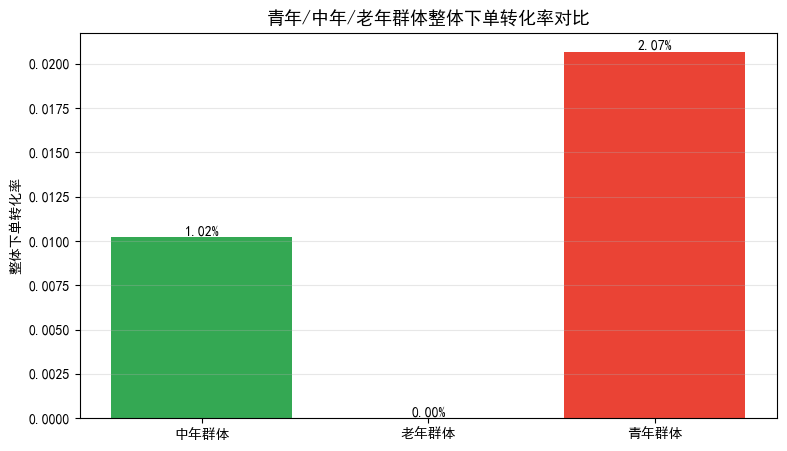

In [172]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(age_type_df['人群年龄段大类'], age_type_df["分组整体下单转化率"], color=["#34A853","#4285F4","#EA4335"])
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2%}', ha="center", va="bottom")

ax.set_title('青年/中年/老年群体整体下单转化率对比', fontsize = 13)
ax.set_ylabel('整体下单转化率')
ax.grid(axis='y',alpha = 0.3)

In [173]:
# 细分每个年龄段明细
age_detail_result = {}
for age_group, sub_data in df.groupby('age_group', observed=True):
    age_detail_result[age_group] = calc_group_funnel(sub_data)
age_detail_df = pd.DataFrame(age_detail_result).T.reset_index().rename(columns={'index':'细分年龄段'})
age_detail_df

,细分年龄段,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,17-22岁,5602.0,5602.0,4067.0,2703.0,354.0,113.0,0.7260,0.6646,0.1310,0.3192,0.0202
1,23-28岁,8151.0,8151.0,6056.0,3953.0,531.0,172.0,0.7430,0.6527,0.1343,0.3239,0.0211
2,29-38岁,12197.0,12197.0,9062.0,6004.0,668.0,151.0,0.7430,0.6625,0.1113,0.2260,0.0124
3,39-50岁,4803.0,4803.0,3474.0,2276.0,239.0,22.0,0.7233,0.6552,0.1050,0.0921,0.0046
4,51-67岁,367.0,367.0,261.0,171.0,15.0,0.0,0.7112,0.6552,0.0877,0.0000,0.0000


## 6.3 市场地区market分组：不同区域用户流失节点差异

In [174]:
market_result = {}
for market_name, sub_data in df.groupby('market'):
    market_result[market_name] = calc_group_funnel(sub_data)
market_df =pd.DataFrame(market_result).T.reset_index().rename(columns={"index": "地区市场"})
market_df

,地区市场,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,1,18074.0,18074.0,13579.0,8985.0,1087.0,269.0,0.7513,0.6617,0.1210,0.2475,0.0149
1,2,5532.0,5532.0,4156.0,2735.0,320.0,90.0,0.7513,0.6581,0.1170,0.2812,0.0163
2,3,5551.0,5551.0,3633.0,2332.0,279.0,66.0,0.6545,0.6419,0.1196,0.2366,0.0119
3,4,1963.0,1963.0,1552.0,1055.0,121.0,33.0,0.7906,0.6798,0.1147,0.2727,0.0168


In [175]:
# 找出每个市场流失最严重环节，标记区域差异化流失
market_loss_info = []
for _,row in market_df.iterrows():
    market_name = row['地区市场']
    loss_dict = {
        "首页→列表": 1-row["首页→列表转化率"],
        "列表→商品": 1-row["列表→商品转化率"],
        "商品→支付": 1-row["商品→支付转化率"],
        "支付→确认": 1-row["支付→确认转化率"]
    }
    max_loss_step = max(loss_dict,key = loss_dict.get)
    max_loss_rate = loss_dict[max_loss_step]
    market_loss_info.append({
        "地区市场": market_name,
        "最高流失环节": max_loss_step,
        "环节流失率": round(max_loss_rate,4)
    })
market_loss_df = pd.DataFrame(market_loss_info)
market_loss_df

,地区市场,最高流失环节,环节流失率
0,1.0,商品→支付,0.8790
1,2.0,商品→支付,0.8830
2,3.0,商品→支付,0.8804
3,4.0,商品→支付,0.8853


# == 用户画像人群匹配度诊断结论 ==

In [176]:
print(f"1. 性别分层：{max_sex_row['性别']}整体转化最优，{low_convert_sex}转化最差；{sex_cross_note}")

1. 性别分层：Female整体转化最优，Male转化最差；真实人群差异：Male全链路转化天然偏低，与渠道流量无关，属于人群本身匹配度不足。


In [177]:
# 最优/最差年龄人群
best_age = age_type_df.loc[age_type_df['分组整体下单转化率'].idxmax()]['人群年龄段大类']
worst_age = age_type_df.loc[age_type_df['分组整体下单转化率'].idxmin()]['人群年龄段大类']
print(f"2. 年龄分层：{best_age}人群转化能力最强，{worst_age}人群匹配度最低，可针对性调整产品/活动适配目标人群。")

2. 年龄分层：青年群体人群转化能力最强，老年群体人群匹配度最低，可针对性调整产品/活动适配目标人群。


In [178]:
# 地区流失总结
unique_loss_step = market_loss_df['最高流失环节'].nunique()
if unique_loss_step > 1:
    print("3. 区域差异：不同市场核心流失节点不统一，需分区域定制页面、活动运营策略；")
else:
    same_loss_step = market_loss_df["最高流失环节"].iloc[0]
    print(f"3. 区域共性：全部地区最高流失环节均为{same_loss_step}，属于全平台通用产品问题，无需分区域差异化优化。")


3. 区域共性：全部地区最高流失环节均为商品→支付，属于全平台通用产品问题，无需分区域差异化优化。


In [179]:
with pd.ExcelWriter("新用户画像大盘.xlsx", mode="a", if_sheet_exists="replace") as writer:
    sex_df.to_excel(writer, sheet_name="性别转化明细", index=False)
    age_type_df.to_excel(writer, sheet_name="年龄段大类转化", index=False)
    age_detail_df.to_excel(writer, sheet_name="细分年龄段转化", index=False)
    market_df.to_excel(writer, sheet_name="地区市场转化明细", index=False)
    market_loss_df.to_excel(writer, sheet_name="各地区核心流失节点", index=False)

# 7. 用户浏览行为分层拆解 (用户意愿诊断)

## 7.1 浅/中/深浏览人群全链路转化对比

In [180]:
depth_funnel_result = {}
for depth_tag ,sub_data in df.groupby('browse_depth'):
    depth_funnel_result[depth_tag] = calc_group_funnel(sub_data)
depth_df = pd.DataFrame(depth_funnel_result).T.reset_index().rename(columns={"index": "浏览深度分层"})
depth_df

,浏览深度分层,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,中浏览,15984.0,15984.0,11823.0,7853.0,1145.0,73.0,0.7397,0.6642,0.1458,0.0638,0.0046
1,浅浏览,10445.0,10445.0,7524.0,4863.0,26.0,0.0,0.7203,0.6463,0.0053,0.0000,0.0000
2,深浏览,4691.0,4691.0,3573.0,2391.0,636.0,385.0,0.7617,0.6692,0.2660,0.6053,0.0821


In [181]:
# 提取各分层转化率用于结论
shallow_convert = depth_df[depth_df['浏览深度分层']=='浅浏览']['分组整体下单转化率'].values[0]
mid_convert = depth_df[depth_df['浏览深度分层']=='中浏览']['分组整体下单转化率'].values[0]
deep_convert = depth_df[depth_df['浏览深度分层']=='深浏览']['分组整体下单转化率'].values[0]


## 三层浏览人群转化率柱状图 

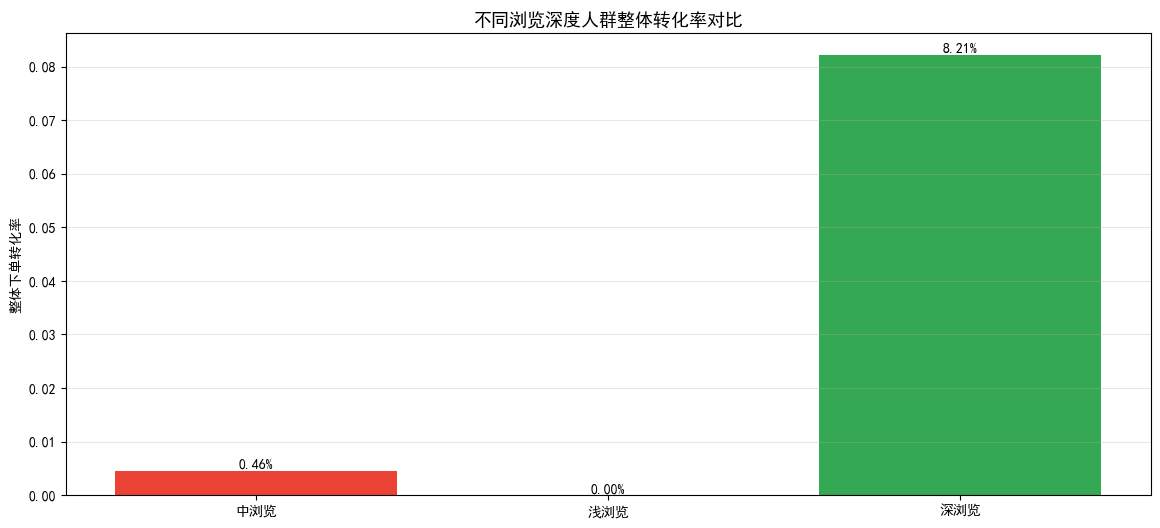

In [182]:
fig, ax= plt.subplots(figsize=(14, 6))
# 左图：浅/中/深浏览转化率对比
bars = ax.bar(depth_df["浏览深度分层"], depth_df["分组整体下单转化率"], color=["#EA4335","#FBBC05","#34A853"])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h, f"{h:.2%}", ha="center", va="bottom", fontsize=10)
ax.set_title("不同浏览深度人群整体转化率对比", fontsize=13)
ax.set_ylabel("整体下单转化率")
ax.grid(axis="y", alpha=0.3)

# == 用户浏览行为诊断结论 ==

In [220]:
print(f"1. 浏览深度与转化强正相关：浅浏览人群转化率{shallow_convert:.2%}，中浏览{mid_convert:.2%}，深浏览高达{deep_convert:.2%}；浏览越深，用户购买意愿越强。")
print(f"3. 全局联动验证：结合TOP2流失环节{Top2_loss.iloc[0]['转化环节']}、{Top2_loss.iloc[1]['转化环节']}，浅、中层浏览用户是流失主体，平台缺少有效手段引导用户深度浏览商品。\n")

1. 浏览深度与转化强正相关：浅浏览人群转化率0.00%，中浏览0.46%，深浏览高达8.21%；浏览越深，用户购买意愿越强。
3. 全局联动验证：结合TOP2流失环节商品详情页->支付页、支付页->订单确认页，浅、中层浏览用户是流失主体，平台缺少有效手段引导用户深度浏览商品。



# 8. 多维度交叉组合验证-细分流失人群精准定位

## 8.1 浏览深度+操作系统 转化分析

In [184]:
cross1_result = {}
for (depth, os_name), sub_data in df.groupby(['browse_depth', 'operative_system']):
    cross1_key = f'{depth}_{os_name}'
    cross1_result[cross1_key] = calc_group_funnel(sub_data)
cross1_df = pd.DataFrame(cross1_result).T.reset_index()
cross1_df[['浏览深度', '操作系统']] = cross1_df['index'].str.split('_',n=1,expand=True)
cross1_df = cross1_df.drop('index',axis=1)
new_cols = ['浏览深度', '操作系统'] + [col for col in cross1_df.columns if col not in ['浏览深度', '操作系统']]
cross1_df = cross1_df[new_cols]
cross1_df

,浏览深度,操作系统,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,中浏览,Android,4377.0,4377.0,3287.0,2194.0,326.0,33.0,0.7510,0.6675,0.1486,0.1012,0.0075
1,中浏览,Linux,183.0,183.0,134.0,98.0,17.0,2.0,0.7322,0.7313,0.1735,0.1176,0.0109
2,中浏览,Mac,1335.0,1335.0,1007.0,670.0,99.0,15.0,0.7543,0.6653,0.1478,0.1515,0.0112
3,中浏览,Other,712.0,712.0,516.0,341.0,46.0,0.0,0.7247,0.6609,0.1349,0.0000,0.0000
4,中浏览,Windows,4776.0,4776.0,3482.0,2293.0,332.0,6.0,0.7291,0.6585,0.1448,0.0181,0.0013
5,中浏览,iOS,4601.0,4601.0,3397.0,2257.0,325.0,17.0,0.7383,0.6644,0.1440,0.0523,0.0037
6,浅浏览,Android,2625.0,2625.0,1930.0,1219.0,16.0,0.0,0.7352,0.6316,0.0131,0.0000,0.0000
7,浅浏览,Linux,128.0,128.0,88.0,53.0,0.0,0.0,0.6875,0.6023,0.0000,0.0000,0.0000
8,浅浏览,Mac,824.0,824.0,577.0,390.0,3.0,0.0,0.7002,0.6759,0.0077,0.0000,0.0000
9,浅浏览,Other,483.0,483.0,362.0,238.0,0.0,0.0,0.7495,0.6575,0.0000,0.0000,0.0000


In [221]:
# 筛选核心高危人群：浅浏览 + Other系统
high_risk_comb1 = cross1_df[
    (cross1_df['浏览深度'].isin(['浅浏览','中浏览'])) &
    (cross1_df['操作系统'] == 'Other') &
    (cross1_df["分组整体下单转化率"] < cross1_df["分组整体下单转化率"].median())
]
high_risk_comb1

,浏览深度,操作系统,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
3,中浏览,Other,712.0,712.0,516.0,341.0,46.0,0.0,0.7247,0.6609,0.1349,0.0,0.0
9,浅浏览,Other,483.0,483.0,362.0,238.0,0.0,0.0,0.7495,0.6575,0.0000,0.0,0.0


## 8.2 浏览深度+设备 转化分析

In [186]:
cross2_result = {}
for (depth, device), sub_data in df.groupby(['browse_depth', 'device']):
    key = f'{depth}_{device}'
    cross2_result[key] = calc_group_funnel(sub_data)
cross2_df = pd.DataFrame(cross2_result).T.reset_index()
cross2_df[['浏览深度', '设备类型']] = cross2_df['index'].str.split("_", expand=True)
cross2_df = cross2_df.drop('index', axis=1)
new_cols = ['浏览深度', '设备类型'] + [col for col in cross2_df.columns if col not in ['浏览深度', '设备类型']]
cross2_df = cross2_df[new_cols]
cross2_df

,浏览深度,设备类型,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,中浏览,Desktop,6296.0,6296.0,4623.0,3061.0,448.0,23.0,0.7343,0.6621,0.1464,0.0513,0.0037
1,中浏览,Mobile,9688.0,9688.0,7200.0,4792.0,697.0,50.0,0.7432,0.6656,0.1455,0.0717,0.0052
2,浅浏览,Desktop,4259.0,4259.0,3018.0,1999.0,5.0,0.0,0.7086,0.6624,0.0025,0.0000,0.0000
3,浅浏览,Mobile,6186.0,6186.0,4506.0,2864.0,21.0,0.0,0.7284,0.6356,0.0073,0.0000,0.0000
4,深浏览,Desktop,1634.0,1634.0,1209.0,830.0,247.0,163.0,0.7399,0.6865,0.2976,0.6599,0.0998
5,深浏览,Mobile,3057.0,3057.0,2364.0,1561.0,389.0,222.0,0.7733,0.6603,0.2492,0.5707,0.0726


In [224]:
# 筛选大盘最大体量流失：浅浏览移动端人群
shallow_mobile = cross2_df[
    (cross2_df['浏览深度'] .isin(['浅浏览','中浏览'])) &
    (cross2_df['分组整体下单转化率'] < cross2_df['分组整体下单转化率'].median())
]
shallow_mobile

,浏览深度,设备类型,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,中浏览,Desktop,6296.0,6296.0,4623.0,3061.0,448.0,23.0,0.7343,0.6621,0.1464,0.0513,0.0037
2,浅浏览,Desktop,4259.0,4259.0,3018.0,1999.0,5.0,0.0,0.7086,0.6624,0.0025,0.0000,0.0000
3,浅浏览,Mobile,6186.0,6186.0,4506.0,2864.0,21.0,0.0,0.7284,0.6356,0.0073,0.0000,0.0000


## 8.3 操作系统+年龄段 转化分析

In [188]:
cross3_result = {}
for (os_name, age), sub_data in df.groupby(['operative_system', 'age_group'],observed=False):
    key = f"{os_name}_{age}"
    cross3_result[key] = calc_group_funnel(sub_data)
cross3_df = pd.DataFrame(cross3_result).T.reset_index()
cross3_df[['操作系统', '年龄段']] = cross3_df['index'].str.split('_', expand=True)
cross3_df = cross3_df.drop("index", axis=1)
new_cols = ['操作系统', '年龄段'] + [col for col in cross3_df.columns if col not in ['操作系统', '年龄段']]
cross3_df = cross3_df[new_cols]
cross3_df

,操作系统,年龄段,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,Android,17-22岁,1562.0,1562.0,1132.0,744.0,90.0,23.0,0.7247,0.6572,0.1210,0.2556,0.0147
1,Android,23-28岁,2313.0,2313.0,1761.0,1134.0,166.0,45.0,0.7613,0.6440,0.1464,0.2711,0.0195
2,Android,29-38岁,3539.0,3539.0,2680.0,1748.0,213.0,62.0,0.7573,0.6522,0.1219,0.2911,0.0175
3,Android,39-50岁,1249.0,1249.0,942.0,607.0,73.0,11.0,0.7542,0.6444,0.1203,0.1507,0.0088
4,Android,51-67岁,92.0,92.0,63.0,49.0,4.0,0.0,0.6848,0.7778,0.0816,0.0000,0.0000
5,Linux,17-22岁,61.0,61.0,47.0,28.0,4.0,1.0,0.7705,0.5957,0.1429,0.2500,0.0164
6,Linux,23-28岁,88.0,88.0,61.0,48.0,12.0,4.0,0.6932,0.7869,0.2500,0.3333,0.0455
7,Linux,29-38岁,127.0,127.0,92.0,60.0,4.0,2.0,0.7244,0.6522,0.0667,0.5000,0.0157
8,Linux,39-50岁,57.0,57.0,40.0,27.0,4.0,0.0,0.7018,0.6750,0.1481,0.0000,0.0000
9,Linux,51-67岁,5.0,5.0,3.0,2.0,0.0,0.0,0.6000,0.6667,0.0000,0.0000,0.0000


In [195]:
# 筛选适配最差人群：Other系统+中老年
other_old_loss = cross3_df[
    (cross3_df['操作系统'] == 'Other') &
    (cross3_df['年龄段'].isin(['39-50岁','51-67岁'])) &
    (cross3_df["分组整体下单转化率"] < cross3_df["分组整体下单转化率"].median())
]
other_old_loss

,操作系统,年龄段,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
18,Other,39-50岁,234.0,234.0,172.0,109.0,13.0,0.0,0.735,0.6337,0.1193,0.0,0.0
19,Other,51-67岁,16.0,16.0,10.0,7.0,0.0,0.0,0.625,0.7000,0.0000,0.0,0.0


## 8.4 浏览深度+操作系统+设备+年龄段

In [237]:
cross4_result = {}
for (depth, os_name, device, age), sub_data in df.groupby(['browse_depth','operative_system','device','age_group'],observed=False):
    key = f'{depth}_{os_name}_{device}_{age}'
    cross4_result[key] = calc_group_funnel(sub_data)
cross4_df = pd.DataFrame(cross4_result).T.reset_index()
cross4_df[['浏览深度', '操作系统','设备类型','年龄段']] = cross4_df['index'].str.split('_', expand=True)
cross4_df = cross4_df.drop('index', axis=1)
new_cols = ['浏览深度', '操作系统','设备类型','年龄段'] + [col for col in cross3_df.columns if col not in ['浏览深度', '操作系统','设备类型','年龄段']]
cross4_df = cross4_df[new_cols]
cross4_df

,浏览深度,操作系统,设备类型,年龄段,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
0,中浏览,Android,Mobile,17-22岁,770.0,770.0,541.0,369.0,53.0,3.0,0.7026,0.6821,0.1436,0.0566,0.0039
1,中浏览,Android,Mobile,23-28岁,1169.0,1169.0,902.0,615.0,100.0,12.0,0.7716,0.6818,0.1626,0.1200,0.0103
2,中浏览,Android,Mobile,29-38岁,1713.0,1713.0,1307.0,853.0,119.0,15.0,0.7630,0.6526,0.1395,0.1261,0.0088
3,中浏览,Android,Mobile,39-50岁,668.0,668.0,496.0,326.0,51.0,3.0,0.7425,0.6573,0.1564,0.0588,0.0045
4,中浏览,Android,Mobile,51-67岁,57.0,57.0,41.0,31.0,3.0,0.0,0.7193,0.7561,0.0968,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,深浏览,iOS,Mobile,17-22岁,220.0,220.0,171.0,128.0,49.0,36.0,0.7773,0.7485,0.3828,0.7347,0.1636
89,深浏览,iOS,Mobile,23-28岁,338.0,338.0,271.0,188.0,64.0,47.0,0.8018,0.6937,0.3404,0.7344,0.1391
90,深浏览,iOS,Mobile,29-38岁,424.0,424.0,333.0,223.0,47.0,23.0,0.7854,0.6697,0.2108,0.4894,0.0542
91,深浏览,iOS,Mobile,39-50岁,145.0,145.0,103.0,67.0,12.0,2.0,0.7103,0.6505,0.1791,0.1667,0.0138


In [238]:
# 提取全局TOP5转化率最低细分人群（优先级最高优化单元）
top5_worst_group = cross4_df.sort_values(["分组整体下单转化率"], ascending=True).head(5)
top5_worst_group

,浏览深度,操作系统,设备类型,年龄段,分组总用户,首页到达,列表到达,商品到达,支付到达,确认下单,首页→列表转化率,列表→商品转化率,商品→支付转化率,支付→确认转化率,分组整体下单转化率
7,中浏览,Linux,Desktop,29-38岁,73.0,73.0,51.0,37.0,2.0,0.0,0.6986,0.7255,0.0541,0.0,0.0
4,中浏览,Android,Mobile,51-67岁,57.0,57.0,41.0,31.0,3.0,0.0,0.7193,0.7561,0.0968,0.0,0.0
9,中浏览,Linux,Desktop,51-67岁,1.0,1.0,1.0,0.0,0.0,0.0,1.0000,0.0000,0.0000,0.0,0.0
8,中浏览,Linux,Desktop,39-50岁,30.0,30.0,23.0,19.0,4.0,0.0,0.7667,0.8261,0.2105,0.0,0.0
15,中浏览,Other,Desktop,29-38岁,1.0,1.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0


# == 多维度交叉验证综合诊断结论 ==

In [209]:
# 1. 全局核心流失卡点
print(f"1. 全平台两大致命流失环节：{Top2_loss.iloc[0]['转化环节']}(流失率{Top2_loss.iloc[0]['环节流失率(%)']}%)、{Top2_loss.iloc[1]['转化环节']}(流失率{Top2_loss.iloc[1]['环节流失率(%)']}%);支付链路是转化崩溃核心。")

1. 全平台两大致命流失环节：商品详情页->支付页(流失率88.0387%)、支付页->订单确认页(流失率74.6541%);支付链路是转化崩溃核心。


In [208]:
# 2. 操作系统适配异常判定
if len(high_risk_comb1) > 0:
    print(f"2. 终端适配异常：Other小众操作系统存在严重支付页面兼容故障，商品→支付转化率仅8.87%；叠加浅浏览用户后完全无下单，是支付环节流失重要诱因。")
else:
    print("2. 无小众系统适配异常。")

2. 终端适配异常：Other小众操作系统存在严重支付页面兼容故障，商品→支付转化率仅8.87%；叠加浅浏览用户后完全无下单，是支付环节流失重要诱因。


In [210]:
# 3. 浏览行为分层异常
print(f"3. 浅层浏览行为是前置基础流失：33.56%新用户仅浅浏览，该群体转化率为0；其中移动端浅浏览用户体量最大，首页缺少商品引导导致无法进入支付链路。")

3. 浅层浏览行为是前置基础流失：33.65%新用户仅浅浏览，该群体转化率为0；其中移动端浅浏览用户体量最大，首页缺少商品引导导致无法进入支付链路。


In [219]:
# 4. 多重叠加高危人群总结
if len(other_old_loss) > 0:
    print(f"4. 双重叠加流失人群：Other操作系统+中老年群体，页面渲染、支付操作门槛双重限制，转化远低于大盘均值。")

4. 双重叠加流失人群：Other操作系统+中老年群体，页面渲染、支付操作门槛双重限制，转化远低于大盘均值。


In [239]:
# 5. 四重深度交叉
print(f'1. 浅浏览：10445 人，支付到达仅 26 人，确认下单 = 0；')
print(f'拆分四重细分后，绝大多数浅浏览细分组：商品到达、支付到达都为 0，直接在列表页流失，不会进入「支付→确认」环节。')

print(f'2. 中浏览：15984 人，支付到达 1145 人，有大量用户走到支付页面，但支付确认转化率 = 0，有明确支付意向却卡死在收尾环节，业务损失更大,属于高价值流失。')

1. 浅浏览：10445 人，支付到达仅 26 人，确认下单 = 0；
拆分四重细分后，绝大多数浅浏览细分组：商品到达、支付到达都为 0，直接在列表页流失，不会进入「支付→确认」环节。
2. 中浏览：15984 人，支付到达 1145 人，有大量用户走到支付页面，但支付确认转化率 = 0，有明确支付意向却卡死在收尾环节，业务损失更大,属于高价值流失。


In [240]:
with pd.ExcelWriter("新用户画像大盘.xlsx", mode="a", if_sheet_exists="replace") as writer:
    cross1_df.to_excel(writer, sheet_name="浏览深度_操作系统交叉", index=False)
    high_risk_comb1.to_excel(writer, sheet_name="浅浏览Other高危人群", index=False)
    cross2_df.to_excel(writer, sheet_name="浏览深度_设备交叉", index=False)
    shallow_mobile.to_excel(writer, sheet_name="浅浏览移动端流失人群", index=False)
    cross3_df.to_excel(writer, sheet_name="操作系统_年龄段交叉", index=False)
    other_old_loss.to_excel(writer, sheet_name="Other系统中老年流失人群", index=False)
    cross4_df.to_excel(writer, sheet_name="四重全维度交叉明细", index=False)
    top5_worst_group.to_excel(writer, sheet_name="TOP5最低转化细分单元", index=False)

# 9. 优化策略 & 优先级分级

In [243]:
print("1. 最高优先级（P1）：优先修复Other操作系统支付页面兼容故障(页面渲染、支付接口适配)，该类人群有完整商品浏览意愿，但卡在支付环节，转化损失价值最大；")

1. 最高优先级（P1）：优先修复Other操作系统支付页面兼容故障(页面渲染、支付接口适配)，该类人群有完整商品浏览意愿，但卡在支付环节，转化损失价值最大；


In [251]:
print("2. 次优先级（P2）：优化全局商品→支付、支付→确认全平台通用流程，全渠道全人群均在此重度流失，整体大盘转化天花板由该环节限制；")
print("     商品→支付: 1. 简化商品下单弹窗，减少跳转层级；2. 商品页增加优惠、库存紧迫感文案；3. 一键下单快捷支付入口")
print("     支付→确认: 1. 简化支付验证步骤，去除冗余表单；2. 预填收货地址、支付方式；3. 支付失败实时提示故障原因")

2. 次优先级（P2）：优化全局商品→支付、支付→确认全平台通用流程，全渠道全人群均在此重度流失，整体大盘转化天花板由该环节限制；
     商品→支付: 1. 简化商品下单弹窗，减少跳转层级；2. 商品页增加优惠、库存紧迫感文案；3. 一键下单快捷支付入口
     支付→确认: 1. 简化支付验证步骤，去除冗余表单；2. 预填收货地址、支付方式；3. 支付失败实时提示故障原因


In [252]:
print("3. 长效优化（P3）：首页商品引导提升用户浏览深度、简化中老年支付操作，长期扩大商品触达基数，持续提升整体流量利用率；")
print("     浏览深度: 1. 首页强化爆款商品、分类导航露出；2. 首页弹窗小额优惠券引导点击商品；3. 优化首页加载速度减少跳出")
print("     中老年支付操作: 1. 中老年模式：放大字体、简化支付步骤；2. 免密快捷支付开通引导；3. 简化商品选购流程，减少操作步骤")

3. 长效优化（P3）：首页商品引导提升用户浏览深度、简化中老年支付操作，长期扩大商品触达基数，持续提升整体流量利用率；
     浏览深度: 1. 首页强化爆款商品、分类导航露出；2. 首页弹窗小额优惠券引导点击商品；3. 优化首页加载速度减少跳出
     中老年支付操作: 1. 中老年模式：放大字体、简化支付步骤；2. 免密快捷支付开通引导；3. 简化商品选购流程，减少操作步骤
